# AI-Based Chest X-ray Disease Classification Using Deep Learning

### Minor Project

This project uses deep learning to classify chest X-ray images into two classes:

- NORMAL
- PNEUMONIA

## 1. Objective

To develop a deep learning-based system for classifying chest X-ray images into NORMAL and PNEUMONIA classes.

## 2. Import Libraries and Environment

In [1]:
import sys
import tensorflow as tf

print("Python version:", sys.version)
print("TensorFlow version:", tf.__version__)

Python version: 3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]
TensorFlow version: 2.21.0


In [2]:
import sys

print(sys.executable)
print(sys.version)

C:\Users\prane\AppData\Local\Python\pythoncore-3.13-64\python.exe
3.13.15 (tags/v3.13.15:4061bc4, Aug  5 2026, 13:05:39) [MSC v.1944 64 bit (AMD64)]


## 3. Dataset

The dataset contains two classes:
- NORMAL
- PNEUMONIA

The dataset is divided into training and testing data.

In [2]:
import os
dataset_path = r"C:\Users\prane\OneDrive\Desktop\minor_project\archive (4)\chest_xray"
print(os.listdir(dataset_path))

['chest_xray', 'test', 'train', 'val', '__MACOSX']


## 4. Load Training Dataset

In [4]:
train_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, "train"),
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

Found 5216 files belonging to 2 classes.


## 5. Dataset Exploration

In [5]:
print("Classes:", train_data.class_names)

Classes: ['NORMAL', 'PNEUMONIA']


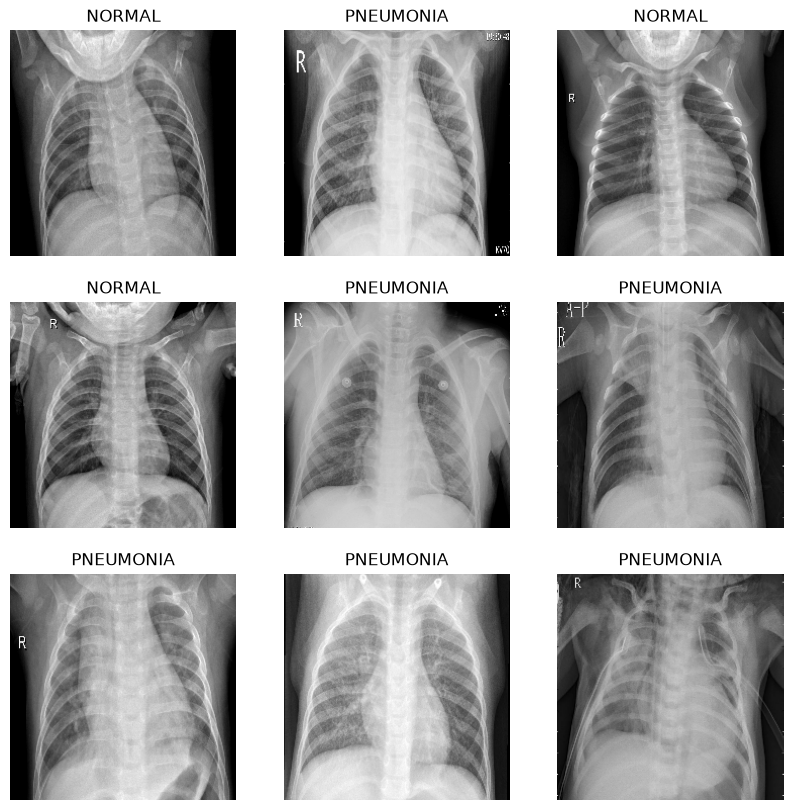

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"), cmap="gray")
        plt.title(train_data.class_names[labels[i]])
        plt.axis("off")

plt.show()

## 6. Data Preprocessing

Images are resized to 224 × 224 pixels and pixel values are normalized to the range 0–1.

In [7]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [10]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(224, 224, 3)),

    normalization_layer,

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [13]:
val_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, "val"),
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 16 files belonging to 2 classes.


In [14]:
print("Validation classes:", val_data.class_names)

for images, labels in val_data:
    print("Number of images in this batch:", len(images))
    print("Labels:", labels.numpy())

Validation classes: ['NORMAL', 'PNEUMONIA']
Number of images in this batch: 16
Labels: [0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1]


In [15]:
test_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, "test"),
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 624 files belonging to 2 classes.


In [16]:
for images, labels in train_data:
    print("Images in first batch:", len(images))
    break

Images in first batch: 32


## 7. Train-Validation-Test Split

In [17]:
train_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, "train"),
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=42
)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.


In [18]:
val_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, "train"),
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=42
)

Found 5216 files belonging to 2 classes.
Using 1043 files for validation.


## 8. Basic CNN Model

In [19]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10


C:\Users\prane\AppData\Local\Python\pythoncore-3.13-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


131/131 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - accuracy: 0.8732 - loss: 0.3231 - val_accuracy: 0.9396 - val_loss: 0.1650
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 159s 1s/step - accuracy: 0.9545 - loss: 0.1257 - val_accuracy: 0.9626 - val_loss: 0.1206
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 645s 5s/step - accuracy: 0.9698 - loss: 0.0899 - val_accuracy: 0.9674 - val_loss: 0.1060
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 900s 7s/step - accuracy: 0.9760 - loss: 0.0694 - val_accuracy: 0.9664 - val_loss: 0.1033
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.9796 - loss: 0.0554 - val_accuracy: 0.9684 - val_loss: 0.1138
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 157s 1s/step - accuracy: 0.9830 - loss: 0.0468 - val_accuracy: 0.9732 - val_loss: 0.1180
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.9842 - loss: 0.0405 - val_accuracy: 0.9751 - val_loss: 0.1172
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.9919 - loss: 0.0234 - val_accuracy: 0.972

In [20]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


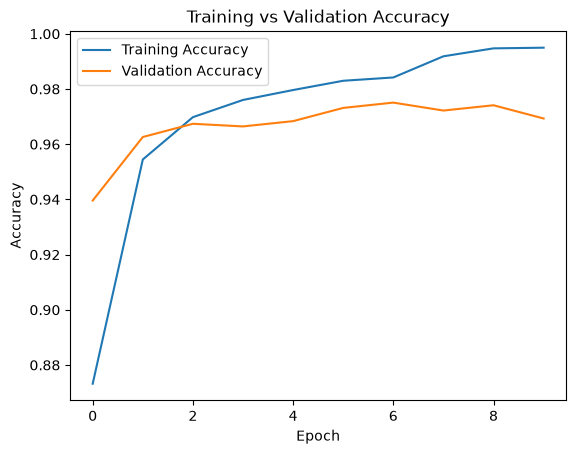

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

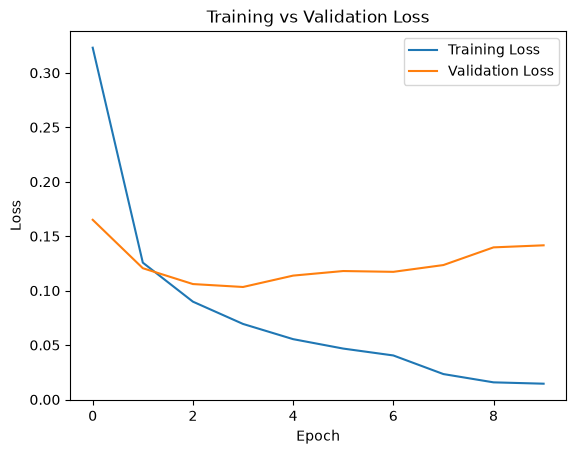

In [22]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [23]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 356ms/step - accuracy: 0.7083 - loss: 2.8553
Test Loss: 2.8553030490875244
Test Accuracy: 0.7083333134651184


In [24]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions.ravel() >= 0.5).astype(int))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Actual labels:", len(y_true))
print("Predicted labels:", len(y_pred))

Actual labels: 624
Predicted labels: 624


[[ 54 180]
 [  2 388]]


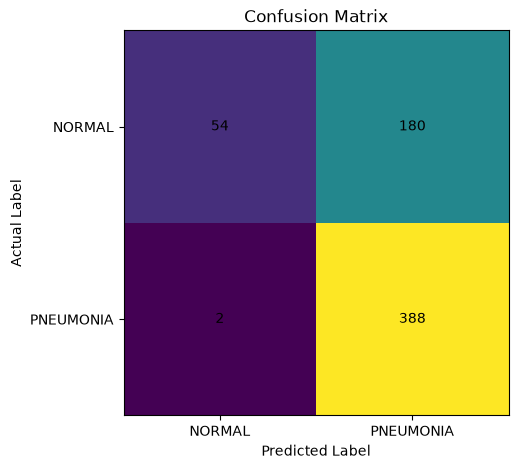

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["NORMAL", "PNEUMONIA"])
plt.yticks([0, 1], ["NORMAL", "PNEUMONIA"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [26]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.96      0.23      0.37       234
   PNEUMONIA       0.68      0.99      0.81       390

    accuracy                           0.71       624
   macro avg       0.82      0.61      0.59       624
weighted avg       0.79      0.71      0.65       624



In [27]:
from collections import Counter

print("Training:", Counter(y for _, labels in train_data for y in labels.numpy()))
print("Test:", Counter(y_true))

Training: Counter({np.int32(1): 3081, np.int32(0): 1092})
Test: Counter({np.int32(1): 390, np.int32(0): 234})


In [28]:
from collections import Counter

val_counts = Counter()

for _, labels in val_data:
    val_counts.update(labels.numpy())

print("Validation:", val_counts)

Validation: Counter({np.int32(1): 794, np.int32(0): 249})


In [29]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=np.array([0] * 1092 + [1] * 3081)
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.9107142857142858), 1: np.float64(0.6772151898734177)}


## 9. Class-Weighted CNN

In [30]:
weighted_model = tf.keras.models.clone_model(model)

In [31]:
weighted_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [32]:
weighted_history = weighted_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weight_dict
)

Epoch 1/10


C:\Users\prane\AppData\Local\Python\pythoncore-3.13-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


131/131 ━━━━━━━━━━━━━━━━━━━━ 79s 594ms/step - accuracy: 0.7891 - loss: 0.4313 - val_accuracy: 0.9348 - val_loss: 0.1948
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 90s 683ms/step - accuracy: 0.9559 - loss: 0.1217 - val_accuracy: 0.9655 - val_loss: 0.1127
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 87s 663ms/step - accuracy: 0.9665 - loss: 0.0881 - val_accuracy: 0.9703 - val_loss: 0.0936
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 87s 662ms/step - accuracy: 0.9660 - loss: 0.0834 - val_accuracy: 0.9722 - val_loss: 0.0991
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 89s 678ms/step - accuracy: 0.9780 - loss: 0.0585 - val_accuracy: 0.9722 - val_loss: 0.1128
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 87s 661ms/step - accuracy: 0.9808 - loss: 0.0506 - val_accuracy: 0.9684 - val_loss: 0.1293
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 92s 696ms/step - accuracy: 0.9861 - loss: 0.0364 - val_accuracy: 0.9712 - val_loss: 0.1395
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 664ms/step - accuracy: 0.9823 - loss: 0.0416 - val

In [33]:
weighted_test_loss, weighted_test_accuracy = weighted_model.evaluate(test_data)

print("Weighted Model Test Loss:", weighted_test_loss)
print("Weighted Model Test Accuracy:", weighted_test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.7452 - loss: 2.2645
Weighted Model Test Loss: 2.26454758644104
Weighted Model Test Accuracy: 0.745192289352417


In [34]:
weighted_y_true = []
weighted_y_pred = []

for images, labels in test_data:
    predictions = weighted_model.predict(images, verbose=0)

    weighted_y_true.extend(labels.numpy())
    weighted_y_pred.extend(
        (predictions.ravel() >= 0.5).astype(int)
    )

weighted_y_true = np.array(weighted_y_true)
weighted_y_pred = np.array(weighted_y_pred)

print("Actual labels:", len(weighted_y_true))
print("Predicted labels:", len(weighted_y_pred))

Actual labels: 624
Predicted labels: 624


[[ 77 157]
 [  2 388]]


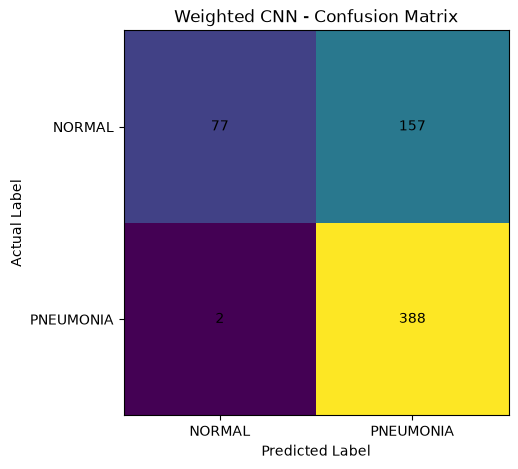

In [35]:
from sklearn.metrics import confusion_matrix

weighted_cm = confusion_matrix(
    weighted_y_true,
    weighted_y_pred
)

print(weighted_cm)

plt.figure(figsize=(6, 5))
plt.imshow(weighted_cm)

plt.title("Weighted CNN - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["NORMAL", "PNEUMONIA"])
plt.yticks([0, 1], ["NORMAL", "PNEUMONIA"])

for i in range(2):
    for j in range(2):
        plt.text(
            j, i,
            weighted_cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [36]:
from sklearn.metrics import classification_report

print(classification_report(
    weighted_y_true,
    weighted_y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.97      0.33      0.49       234
   PNEUMONIA       0.71      0.99      0.83       390

    accuracy                           0.75       624
   macro avg       0.84      0.66      0.66       624
weighted avg       0.81      0.75      0.70       624



## 10. Improved CNN with Data Augmentation and Dropout

In [37]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

In [38]:
improved_model = tf.keras.Sequential([
    tf.keras.Input(shape=(224, 224, 3)),

    data_augmentation,
    normalization_layer,

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

improved_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

improved_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

improved_history = improved_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/10


C:\Users\prane\AppData\Local\Python\pythoncore-3.13-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


131/131 ━━━━━━━━━━━━━━━━━━━━ 88s 660ms/step - accuracy: 0.7402 - loss: 0.4985 - val_accuracy: 0.8715 - val_loss: 0.3602
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 93s 705ms/step - accuracy: 0.8912 - loss: 0.2785 - val_accuracy: 0.8734 - val_loss: 0.2837
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 95s 725ms/step - accuracy: 0.9099 - loss: 0.2143 - val_accuracy: 0.9501 - val_loss: 0.1433
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 95s 719ms/step - accuracy: 0.9267 - loss: 0.1845 - val_accuracy: 0.9367 - val_loss: 0.1651
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 94s 710ms/step - accuracy: 0.9295 - loss: 0.1755 - val_accuracy: 0.9636 - val_loss: 0.1186
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 95s 718ms/step - accuracy: 0.9408 - loss: 0.1543 - val_accuracy: 0.9530 - val_loss: 0.1423
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 97s 740ms/step - accuracy: 0.9372 - loss: 0.1523 - val_accuracy: 0.9722 - val_loss: 0.0924
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 96s 725ms/step - accuracy: 0.9480 - loss: 0.1300 - val

In [40]:
improved_test_loss, improved_test_accuracy = improved_model.evaluate(test_data)

print("Improved Test Loss:", improved_test_loss)
print("Improved Test Accuracy:", improved_test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - accuracy: 0.8237 - loss: 0.4874
Improved Test Loss: 0.4874226450920105
Improved Test Accuracy: 0.8237179517745972


In [41]:
improved_y_true = []
improved_y_pred = []

for images, labels in test_data:
    predictions = improved_model.predict(images, verbose=0)

    improved_y_true.extend(labels.numpy())
    improved_y_pred.extend(
        (predictions.ravel() >= 0.5).astype(int)
    )

improved_y_true = np.array(improved_y_true)
improved_y_pred = np.array(improved_y_pred)

improved_cm = confusion_matrix(
    improved_y_true,
    improved_y_pred
)

print(improved_cm)

[[130 104]
 [  6 384]]


In [42]:
print(classification_report(
    improved_y_true,
    improved_y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

              precision    recall  f1-score   support

      NORMAL       0.96      0.56      0.70       234
   PNEUMONIA       0.79      0.98      0.87       390

    accuracy                           0.82       624
   macro avg       0.87      0.77      0.79       624
weighted avg       0.85      0.82      0.81       624



## 11. Transfer Learning Using MobileNetV3Small

In [43]:
from tensorflow.keras.applications import MobileNetV3Small

base_model = MobileNetV3Small(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 4s 1us/step


In [44]:
transfer_model = tf.keras.Sequential([
    tf.keras.Input(shape=(224, 224, 3)),

    data_augmentation,

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation="relu"),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

transfer_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ MobileNetV3Small (Functional)        │ (None, 7, 7, 576)           │         939,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 576)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 576)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 976,113 (3.72 MB)

 Trainable params: 36,993 (144.50 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [45]:
transfer_history = transfer_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/10


C:\Users\prane\AppData\Local\Python\pythoncore-3.13-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


131/131 ━━━━━━━━━━━━━━━━━━━━ 28s 172ms/step - accuracy: 0.8497 - loss: 0.3175 - val_accuracy: 0.9032 - val_loss: 0.2446
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 24s 181ms/step - accuracy: 0.9207 - loss: 0.1919 - val_accuracy: 0.9310 - val_loss: 0.1670
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 27s 205ms/step - accuracy: 0.9221 - loss: 0.1808 - val_accuracy: 0.9358 - val_loss: 0.1418
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 27s 208ms/step - accuracy: 0.9399 - loss: 0.1443 - val_accuracy: 0.9070 - val_loss: 0.2195
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 28s 214ms/step - accuracy: 0.9353 - loss: 0.1598 - val_accuracy: 0.9300 - val_loss: 0.1662


In [46]:
transfer_test_loss, transfer_test_accuracy = transfer_model.evaluate(test_data)

print("Transfer Learning Test Loss:", transfer_test_loss)
print("Transfer Learning Test Accuracy:", transfer_test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.8750 - loss: 0.3580
Transfer Learning Test Loss: 0.3579694330692291
Transfer Learning Test Accuracy: 0.875


In [47]:
transfer_y_true = []
transfer_y_pred = []

for images, labels in test_data:
    predictions = transfer_model.predict(images, verbose=0)

    transfer_y_true.extend(labels.numpy())
    transfer_y_pred.extend(
        (predictions.ravel() >= 0.5).astype(int)
    )

transfer_y_true = np.array(transfer_y_true)
transfer_y_pred = np.array(transfer_y_pred)

transfer_cm = confusion_matrix(
    transfer_y_true,
    transfer_y_pred
)

print(transfer_cm)

print(classification_report(
    transfer_y_true,
    transfer_y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

[[168  66]
 [ 12 378]]
              precision    recall  f1-score   support

      NORMAL       0.93      0.72      0.81       234
   PNEUMONIA       0.85      0.97      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.84      0.86       624
weighted avg       0.88      0.88      0.87       624



In [48]:
transfer_model.save("chest_xray_mobilenetv3.keras")

In [49]:
normal_folder = os.path.join(dataset_path, "test", "NORMAL")

image_name = os.listdir(normal_folder)[0]

image_path = os.path.join(normal_folder, image_name)

print("Image:", image_path)

Image: C:\Users\prane\OneDrive\Desktop\minor_project\archive (4)\chest_xray\test\NORMAL\IM-0001-0001.jpeg


In [50]:
img = tf.keras.utils.load_img(
    image_path,
    target_size=(224, 224)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = tf.expand_dims(img_array, axis=0)

prediction = transfer_model.predict(
    img_array,
    verbose=0
)[0][0]

if prediction >= 0.5:
    result = "PNEUMONIA"
    confidence = prediction
else:
    result = "NORMAL"
    confidence = 1 - prediction

print("Prediction:", result)
print("Confidence:", round(confidence * 100, 2), "%")

Prediction: NORMAL
Confidence: 83.68 %


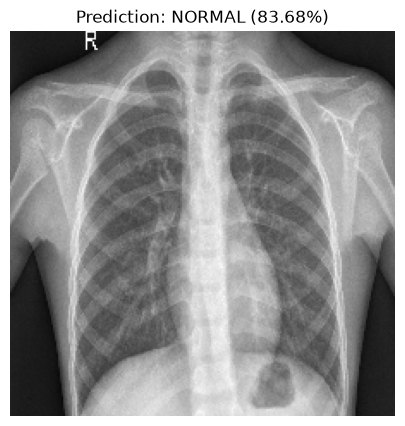

In [51]:
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Prediction: {result} ({confidence*100:.2f}%)")
plt.axis("off")
plt.show()

## 12. Single X-ray Prediction

In [52]:
def predict_xray(image_path):
    img = tf.keras.utils.load_img(
        image_path,
        target_size=(224, 224)
    )

    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, axis=0)

    prediction = transfer_model.predict(
        img_array,
        verbose=0
    )[0][0]

    if prediction >= 0.5:
        result = "PNEUMONIA"
        confidence = prediction
    else:
        result = "NORMAL"
        confidence = 1 - prediction

    print("Prediction:", result)
    print("Confidence:", round(confidence * 100, 2), "%")

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"{result} ({confidence * 100:.2f}%)")
    plt.axis("off")
    plt.show()

Prediction: NORMAL
Confidence: 83.68 %


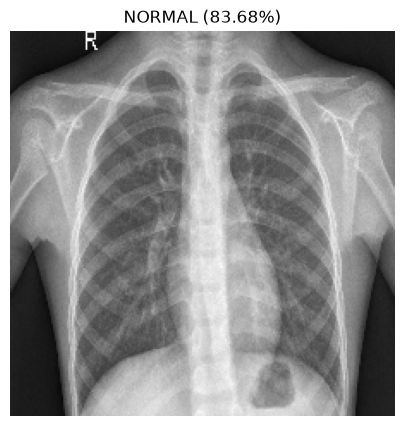

In [53]:
predict_xray(image_path)

Prediction: PNEUMONIA
Confidence: 79.78 %


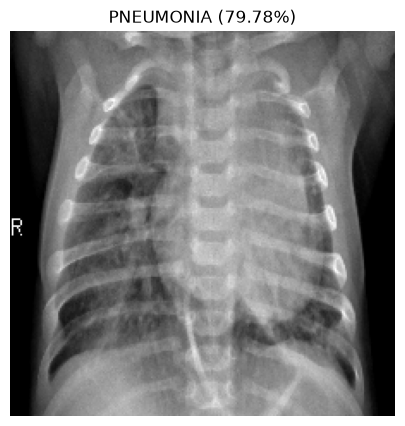

In [54]:
pneumonia_folder = os.path.join(dataset_path, "test", "PNEUMONIA")

pneumonia_image = os.path.join(
    pneumonia_folder,
    os.listdir(pneumonia_folder)[0]
)

predict_xray(pneumonia_image)

In [55]:
transfer_model.save("chest_xray_mobilenetv3.keras")
print("Model saved successfully!")

Model saved successfully!


## 13. Model Comparison

In [56]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Basic CNN",
        "Weighted CNN",
        "Improved CNN",
        "MobileNetV3Small"
    ],
    "Test Accuracy": [
        0.7083,
        0.7452,
        0.8237,
        0.8750
    ]
})

print(results)

              Model  Test Accuracy
0         Basic CNN         0.7083
1      Weighted CNN         0.7452
2      Improved CNN         0.8237
3  MobileNetV3Small         0.8750


In [58]:
results["Test Accuracy"] = results["Test Accuracy"] * 100
results

,Model,Test Accuracy
0,Basic CNN,70.83
1,Weighted CNN,74.52
2,Improved CNN,82.37
3,MobileNetV3Small,87.50


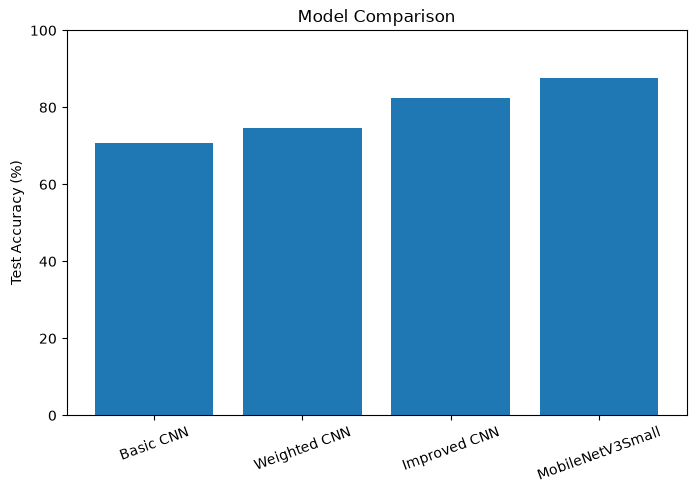

In [59]:
plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["Test Accuracy"])

plt.ylabel("Test Accuracy (%)")
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.ylim(0, 100)

plt.show()

In [67]:
import io

def predict_uploaded_xray():

    if not upload.value:
        print("Please upload an X-ray image.")
        return

    # Get the uploaded file
    file_info = upload.value[0]

    # Get the image data
    image_data = file_info["content"]

    # Load and resize the image
    img = tf.keras.utils.load_img(
        io.BytesIO(image_data),
        target_size=(224, 224)
    )

    # Convert image to numbers
    img_array = tf.keras.utils.img_to_array(img)

    # Add batch dimension
    img_array = tf.expand_dims(img_array, axis=0)

    # Make prediction
    prediction = transfer_model.predict(
        img_array,
        verbose=0
    )[0][0]

    # Convert probability to class
    if prediction >= 0.5:
        result = "PNEUMONIA"
        confidence = prediction
    else:
        result = "NORMAL"
        confidence = 1 - prediction

    print("Prediction:", result)
    print("Model confidence:", round(confidence * 100, 2), "%")

    # Display image
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Prediction: {result} ({confidence * 100:.2f}%)")
    plt.axis("off")
    plt.show()

In [68]:
import ipywidgets as widgets
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

upload = widgets.FileUpload(
    accept=".jpg,.jpeg,.png",
    multiple=False
)

display(upload)

FileUpload(value=(), accept='.jpg,.jpeg,.png', description='Upload')

Prediction: PNEUMONIA
Model confidence: 99.69 %


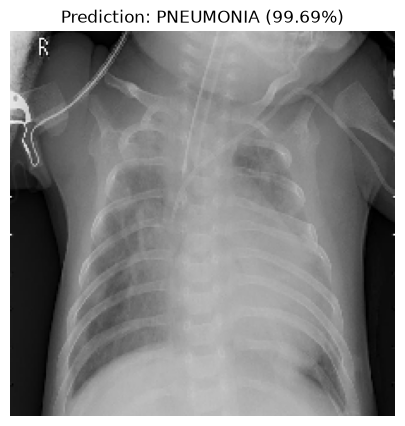

In [69]:
predict_uploaded_xray()

In [70]:
transfer_model.save("chest_xray_mobilenetv3.keras")
print("Final model saved!")

Final model saved!


In [71]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Basic CNN",
        "Weighted CNN",
        "Improved CNN",
        "MobileNetV3Small"
    ],
    "Test Accuracy (%)": [
        70.83,
        74.52,
        82.37,
        87.50
    ]
})

results

,Model,Test Accuracy (%)
0,Basic CNN,70.83
1,Weighted CNN,74.52
2,Improved CNN,82.37
3,MobileNetV3Small,87.50


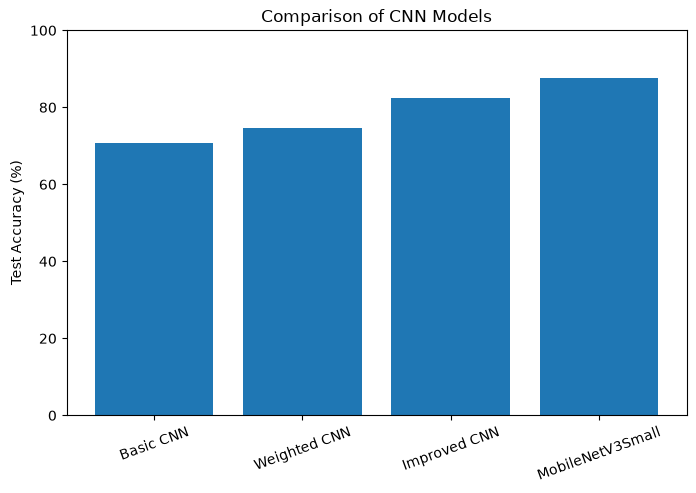

In [72]:
plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["Test Accuracy (%)"])

plt.ylabel("Test Accuracy (%)")
plt.title("Comparison of CNN Models")
plt.ylim(0, 100)
plt.xticks(rotation=20)

plt.show()

In [73]:
plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

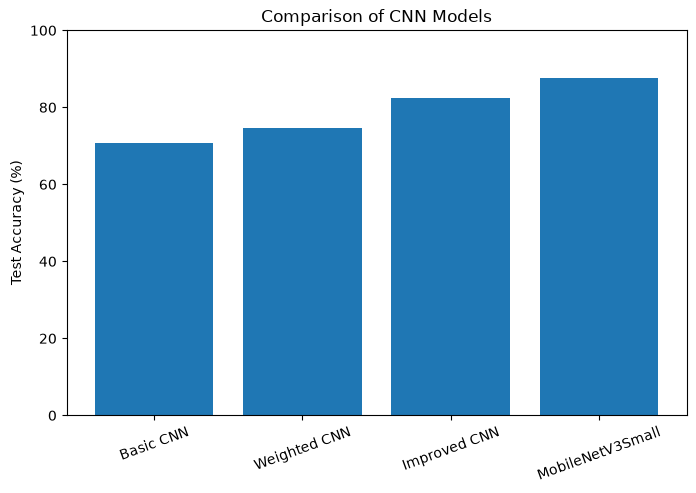

In [74]:
plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["Test Accuracy (%)"])

plt.ylabel("Test Accuracy (%)")
plt.title("Comparison of CNN Models")
plt.ylim(0, 100)
plt.xticks(rotation=20)

plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

In [75]:
transfer_model.save("chest_xray_mobilenetv3.keras")
print("Final model saved successfully!")

Final model saved successfully!


In [2]:
import os

print(os.path.exists("chest_xray_mobilenetv3.keras"))

True


In [3]:
print(os.getcwd())

C:\Users\prane\OneDrive\Desktop\minor_project


In [1]:
import tensorflow as tf

transfer_model = tf.keras.models.load_model(
    "chest_xray_mobilenetv3.keras"
)

print("Model loaded successfully!")

Model loaded successfully!


In [2]:
transfer_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ MobileNetV3Small (Functional)        │ (None, 7, 7, 576)           │         939,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 576)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 576)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,050,101 (4.01 MB)

 Trainable params: 36,993 (144.50 KB)

 Non-trainable params: 939,120 (3.58 MB)

 Optimizer params: 73,988 (289.02 KB)

In [3]:
import os
import numpy as np
import tensorflow as tf

dataset_path = r"C:\Users\prane\OneDrive\Desktop\minor_project\archive (4)\chest_xray"

train_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, "train"),
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=42
)

val_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, "train"),
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=42
)

class_weight_dict = {
    0: 1.9107142857,
    1: 0.6772151899
}

print("Training and validation data loaded.")

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Training and validation data loaded.


In [4]:
base_model = transfer_model.layers[1]

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)            │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ MobileNetV3Small (Functional)        │ (None, 7, 7, 576)           │         939,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 576)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 576)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 976,113 (3.72 MB)

 Trainable params: 625,185 (2.38 MB)

 Non-trainable params: 350,928 (1.34 MB)

In [5]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

fine_tune_history = transfer_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/10


C:\Users\prane\AppData\Local\Python\pythoncore-3.13-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


131/131 ━━━━━━━━━━━━━━━━━━━━ 101s 633ms/step - accuracy: 0.8186 - loss: 0.3313 - val_accuracy: 0.9597 - val_loss: 0.1090
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 132s 559ms/step - accuracy: 0.8826 - loss: 0.2443 - val_accuracy: 0.9578 - val_loss: 0.1108
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 79s 594ms/step - accuracy: 0.9075 - loss: 0.2100 - val_accuracy: 0.9588 - val_loss: 0.1128


In [7]:
test_data = tf.keras.utils.image_dataset_from_directory(
    os.path.join(dataset_path, "test"),
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

print("Test dataset loaded.")

Found 624 files belonging to 2 classes.
Test dataset loaded.


In [8]:
fine_test_loss, fine_test_accuracy = transfer_model.evaluate(test_data)

print("Fine-tuned Test Loss:", fine_test_loss)
print("Fine-tuned Test Accuracy:", fine_test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 275ms/step - accuracy: 0.8157 - loss: 0.5199
Fine-tuned Test Loss: 0.5198888778686523
Fine-tuned Test Accuracy: 0.8157051205635071


In [9]:
transfer_model = tf.keras.models.load_model(
    "chest_xray_mobilenetv3.keras"
)

print("Original MobileNetV3 model restored.")

Original MobileNetV3 model restored.


In [11]:
test_loss, test_accuracy = transfer_model.evaluate(test_data)

print("Original Test Loss:", test_loss)
print("Original Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 282ms/step - accuracy: 0.8750 - loss: 0.3580
Original Test Loss: 0.3579694330692291
Original Test Accuracy: 0.875


In [12]:
import os

print(os.path.exists("chest_xray_mobilenetv3.keras"))

True
